## Stable Diffusion

#### 사전학습된 Stable Diffusion 

In [3]:
!pip install --upgrade pip
!pip install diffusers transformers accelerate --upgrade --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 25.1.1
    Uninstalling pip-25.1.1:
      Successfully uninstalled pip-25.1.1


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

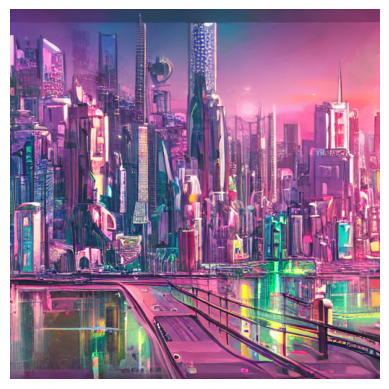

In [2]:
import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import numpy as np
import math
from PIL import Image

# GPU가 사용 가능한지 확인하고, 사용 가능한 경우 GPU와 float16을 설정합니다.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Pre-trained Stable Diffusion 모델을 불러옵니다.
# 모델 아이디는 원하는 버전(예: "CompVis/stable-diffusion-v1-4" 또는 "runwayml/stable-diffusion-v1-5")에 따라 조정할 수 있습니다.
model_id = "CompVis/stable-diffusion-v1-4"

pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to(device)

# 아래 한 줄을 추가하여 Safety Checker를 비활성화합니다.
pipe.safety_checker = None

# 이제 pipe를 사용하여 텍스트-투-이미지 생성 등을 수행할 수 있습니다.
prompt = "A futuristic cityscape, vibrant and detailed"
image = pipe(prompt).images[0]

# 생성된 이미지를 출력합니다.
plt.imshow(np.array(image))
plt.axis("off")
plt.show()

#### 텍스트 프롬프트1와 프롬프트2 사이 관찰하기

In [3]:
# 프롬프트와 보간 단계 수 정의
prompt_1 = "A watercolor painting of a Golden Retriever at the beach"
prompt_2 = "A still life DSLR photo of a bowl of fruit"
interpolation_steps = 5

# 토크나이저를 사용해 텍스트를 토큰화합니다.
inputs_1 = pipe.tokenizer(prompt_1, padding="max_length", max_length=pipe.tokenizer.model_max_length, return_tensors="pt")
inputs_2 = pipe.tokenizer(prompt_2, padding="max_length", max_length=pipe.tokenizer.model_max_length, return_tensors="pt")

# CPU에 있는 텐서를 GPU로 이동
inputs_1 = {k: v.to(device) for k, v in inputs_1.items()}
inputs_2 = {k: v.to(device) for k, v in inputs_2.items()}

# 텍스트 인코더를 사용해 프롬프트의 임베딩을 얻습니다.
with torch.no_grad():
    encoding_1 = pipe.text_encoder(**inputs_1).last_hidden_state  # shape: (1, seq_len, emb_dim)
    encoding_2 = pipe.text_encoder(**inputs_2).last_hidden_state

# 배치 차원 제거 (1, seq_len, emb_dim) -> (seq_len, emb_dim)
encoding_1 = encoding_1.squeeze(0)
encoding_2 = encoding_2.squeeze(0)

# 두 인코딩 사이를 선형 보간합니다.
alphas = torch.linspace(0, 1, steps=interpolation_steps, device=encoding_1.device)
# 각 보간 단계마다 encoding_1과 encoding_2의 가중 평균을 계산합니다.
interpolated_encodings = [(1 - alpha) * encoding_1 + alpha * encoding_2 for alpha in alphas]
# 보간 결과를 하나의 텐서로 스택 (shape: (interpolation_steps, seq_len, emb_dim))
interpolated_encodings = torch.stack(interpolated_encodings)

# 임베딩의 shape 출력
print(f"Encoding shape: {encoding_1.shape}")

Encoding shape: torch.Size([77, 768])


In [4]:
import torch

# 시드 설정 및 생성기 초기화
seed = 12345
generator = torch.Generator(device=device).manual_seed(seed)

# latent 공간 크기: (batch_size, 4, height, width)
latent_height = 512 // 8  # 64
latent_width = 512 // 8   # 64

# interpolation_steps 만큼의 노이즈(초기 잠재 변수)를 생성
latents = torch.randn(
    (interpolation_steps, 4, latent_height, latent_width),
    generator=generator,
    dtype=torch.float16,
    device=device
)

# 파이프라인 호출: prompt_embeds에 보간된 텍스트 임베딩을,
# latents에 미리 생성한 노이즈를 전달합니다.
images = pipe(
    prompt_embeds=interpolated_encodings,
    latents=latents,
    generator=generator
).images

  0%|          | 0/50 [00:00<?, ?it/s]

In [5]:
from PIL import Image

def export_as_gif(filename, images, frames_per_second=10, rubber_band=False):
    if rubber_band:
        images += images[2:-1][::-1]
    images[0].save(
        filename,
        save_all=True,
        append_images=images[1:],
        duration=1000 // frames_per_second,
        loop=0,
    )

# images는 diffusers 파이프라인에서 생성된 PIL 이미지 리스트라고 가정합니다.
export_as_gif(
    "doggo-and-fruit-5.gif",
    images,  # 만약 numpy 배열이라면, [Image.fromarray(img) for img in images]로 변환
    frames_per_second=2,
    rubber_band=True,
)

In [6]:
import math
import torch
from PIL import Image

# 설정
interpolation_steps = 150  # 원래 생성할 샘플 수
batch_size = 3

# interpolated_encodings는 이전에 (interpolation_steps, 77, 768) 모양으로 생성됨
total = interpolated_encodings.shape[0]
num_batches = math.ceil(total / batch_size)
padding_size = num_batches * batch_size - total

if padding_size > 0:
    # 마지막 샘플을 복제해서 패딩 (여기서는 마지막 샘플을 반복)
    pad_encodings = interpolated_encodings[-1:].expand(padding_size, -1, -1)
    interpolated_encodings = torch.cat([interpolated_encodings, pad_encodings], dim=0)

# 이제 전체 샘플 수는 num_batches * batch_size가 됨
batched_encodings = torch.split(interpolated_encodings, batch_size)

# 잠재(latent) 공간의 크기 계산 (일반적으로 512/8 = 64)
latent_height = 512 // 8  # 64
latent_width = 512 // 8   # 64

# 각 보간 단계마다 사용할 노이즈(초기 잠재 변수)를 생성합니다.
# noise 텐서의 shape: (interpolation_steps, 4, latent_height, latent_width)
noise = torch.randn(
    (total, 4, latent_height, latent_width),
    generator=generator,
    dtype=torch.float16,
    device=device
)
# noise도 배치 크기의 배수가 아니면 패딩
if padding_size > 0:
    pad_noise = noise[-1:].expand(padding_size, 4, latent_height, latent_width)
    noise = torch.cat([noise, pad_noise], dim=0)

batched_latents = torch.split(noise, batch_size)

# 배치별로 이미지를 생성합니다.
images = []
for i in range(len(batched_encodings)):
    output = pipe(
        prompt_embeds=batched_encodings[i],
        latents=batched_latents[i],
        num_inference_steps=25,
        generator=generator
    )
    images += output.images

# export_as_gif 함수는 이전에 정의한 대로 PIL 이미지 리스트를 GIF로 저장합니다.
export_as_gif("doggo-and-fruit-150.gif", images, rubber_band=True)

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

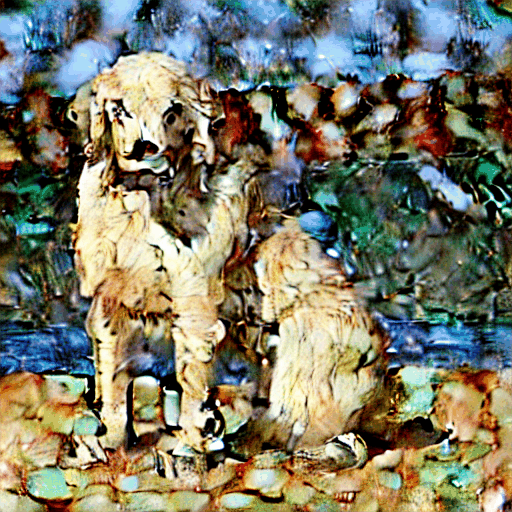

In [7]:
from IPython.display import Image

Image(filename='/home/jovyan/work/AIFFEL_quest_rs/GoingDeeper/Quest_09/doggo-and-fruit-150.gif')

In [8]:
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 프롬프트 정의
prompt_1 = "A watercolor painting of a Golden Retriever at the beach"
prompt_2 = "A still life DSLR photo of a bowl of fruit"
prompt_3 = "The eiffel tower in the style of starry night"
prompt_4 = "An architectural sketch of a skyscraper"

# 보간 관련 설정
interpolation_steps = 6
batch_size = 3
# 총 생성할 임베딩 수: 6 * 6 = 36, 배치 수 = 36 // 3 = 12
batches = (interpolation_steps**2) // batch_size

# 텍스트 인코딩 함수 (diffusers 파이프라인의 tokenizer, text_encoder 사용)
def get_encoding(prompt):
    inputs = pipe.tokenizer(
        prompt,
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        return_tensors="pt"
    )
    # GPU에 올리기
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        encoding = pipe.text_encoder(**inputs).last_hidden_state  # shape: (1, seq_len, emb_dim)
    return encoding.squeeze(0).to(device)  # shape: (seq_len, emb_dim)

# 각 프롬프트에 대한 인코딩을 GPU로 가져옵니다.
encoding_1 = get_encoding(prompt_1)
encoding_2 = get_encoding(prompt_2)
encoding_3 = get_encoding(prompt_3)
encoding_4 = get_encoding(prompt_4)

# 1차 보간: encoding_1 ~ encoding_2, encoding_3 ~ encoding_4
alphas = torch.linspace(0, 1, interpolation_steps, device=device)
lin1 = torch.stack([ (1 - alpha) * encoding_1 + alpha * encoding_2 for alpha in alphas ])
lin2 = torch.stack([ (1 - alpha) * encoding_3 + alpha * encoding_4 for alpha in alphas ])

# 2차 보간: lin1 ~ lin2 (결과 shape: (interpolation_steps, interpolation_steps, seq_len, emb_dim))
betas = torch.linspace(0, 1, interpolation_steps, device=device)
interpolated_encodings = torch.stack([ (1 - beta) * lin1 + beta * lin2 for beta in betas ])

# reshape to (interpolation_steps**2, seq_len, emb_dim) => (36, 77, 768)
interpolated_encodings = interpolated_encodings.view(interpolation_steps**2, *lin1.shape[1:])
# 보간된 임베딩을 GPU로 확실히 옮깁니다.
interpolated_encodings = interpolated_encodings.to(device)

# 배치별로 분할 (각 배치에 batch_size개씩)
batched_encodings = torch.split(interpolated_encodings, batch_size)

# 이미지 생성을 위한 latent 공간의 크기 (일반적으로 512/8 = 64)
latent_height = 512 // 8  # 64
latent_width = 512 // 8   # 64

images = []
# 각 배치마다 노이즈(초기 잠재 변수)를 생성하고 파이프라인 호출
for batch in batched_encodings:
    current_batch_size = batch.shape[0]
    # latents를 생성할 때도 device, dtype 등이 올바른지 확인합니다.
    latents = torch.randn(
        (current_batch_size, 4, latent_height, latent_width),
        generator=generator,
        dtype=torch.float16,
        device=device
    )
    # 배치의 텍스트 임베딩도 GPU에 있는지 확인 (to(device) 호출)
    batch = batch.to(device)
    output = pipe(
        prompt_embeds=batch,
        latents=latents,
        num_inference_steps=25,
        generator=generator
    )
    images.extend(output.images)  # output.images: PIL 이미지 객체 리스트

# grid를 만들어 이미지를 저장하는 함수
def plot_grid(images, path, grid_size, scale=2):
    fig = plt.figure(figsize=(grid_size * scale, grid_size * scale))
    fig.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.margins(x=0, y=0)
    for row in range(grid_size):
        for col in range(grid_size):
            index = row * grid_size + col
            ax = plt.subplot(grid_size, grid_size, index + 1)
            ax.imshow(np.array(images[index]))
            ax.axis("off")
            plt.margins(x=0, y=0)
    plt.savefig(fname=path, pad_inches=0, bbox_inches="tight", transparent=False, dpi=60)
    plt.close(fig)

# grid_size는 interpolation_steps (6)
plot_grid(images, "4-way-interpolation.jpg", interpolation_steps)

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

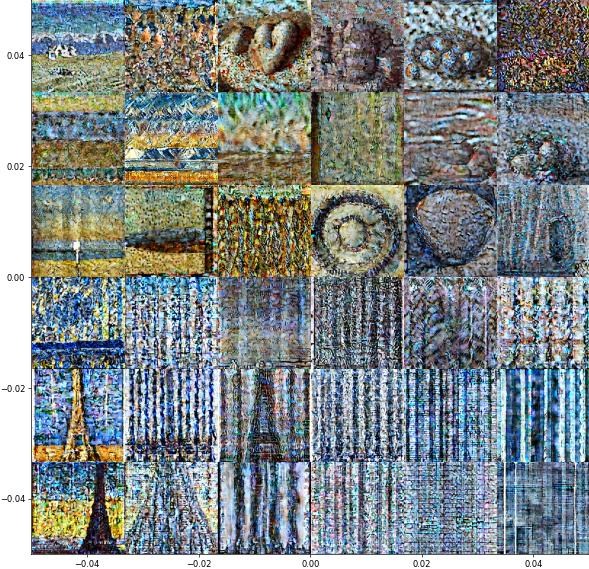

### 잠재 공간 탐색 (latent space walk)

In [9]:
# 약 10분 정도 걸립니다.
walk_steps = 150
batch_size = 3
batches = walk_steps // batch_size  # 예: 150 / 3 = 50
step_size = 0.005

# "The Eiffel Tower in the style of starry night" 프롬프트에 대한 텍스트 인코딩 얻기
# get_encoding 함수는 이전에 정의된 함수로, 프롬프트를 토큰화하고 텍스트 인코딩을 반환합니다.
encoding = get_encoding("The Eiffel Tower in the style of starry night")  # shape: (77, 768)

# 각 스텝마다 더할 변화량(delta) 생성
delta = torch.ones_like(encoding) * step_size

# 워크 스텝에 따른 인코딩 리스트 생성 (각 스텝마다 인코딩에 delta를 더함)
walked_encodings = []
for step_index in range(walk_steps):
    # clone()을 사용하여 현재 encoding의 복사본을 저장 (참조가 누적되지 않도록)
    walked_encodings.append(encoding.clone())
    encoding = encoding + delta

# walked_encodings의 shape: (walk_steps, 77, 768)
walked_encodings = torch.stack(walked_encodings)
# 배치 크기(batch_size)로 분할: 총 (150 / 3) = 50개의 배치 생성
batched_encodings = torch.split(walked_encodings, batch_size)

# 이미지 생성
images = []
for batch in batched_encodings:
    current_batch_size = batch.shape[0]
    # 잠재(latent) 공간 크기: (batch_size, 4, latent_height, latent_width)
    latents = torch.randn(
        (current_batch_size, 4, latent_height, latent_width),
        generator=generator,
        dtype=torch.float16,
        device=device
    )
    # 파이프라인 호출: 텍스트 임베딩(prompt_embeds)와 초기 잠재(latents)를 사용하여 이미지를 생성
    output = pipe(
        prompt_embeds=batch,
        latents=latents,
        num_inference_steps=25,
        generator=generator
    )
    images.extend(output.images)  # output.images는 PIL 이미지 객체 리스트

# GIF로 내보내기 (export_as_gif 함수는 이전에 정의된 함수)
export_as_gif("eiffel-tower-starry-night.gif", images, rubber_band=True)

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
import torch
import math
from PIL import Image

# 전제: device, generator, pipe, export_as_gif, get_encoding 함수는 이미 정의되어 있다고 가정합니다.
# 예: device = "cuda" if torch.cuda.is_available() else "cpu"

prompt = "An oil paintings of cows in a field next to a windmill in Holland"
# get_encoding 함수는 이전에 정의한 텍스트 인코딩 함수 (출력 shape: (seq_len, emb_dim))
encoding = get_encoding(prompt)  # shape: (77, 768)

walk_steps = 150
batch_size = 3
batches = walk_steps // batch_size  # 150/3 = 50

# 잠재(latent) 공간 크기 설정 (일반적으로 512/8 = 64)
latent_channels = 4
latent_height = 512 // 8  # 64
latent_width = 512 // 8   # 64

# base noise shape: (4, 64, 64)
base_noise_shape = (latent_channels, latent_height, latent_width)

# 두 방향의 난수 노이즈 (dtype는 torch.float64로 생성 후, 나중에 float16로 변환)
walk_noise_x = torch.randn(base_noise_shape, dtype=torch.float64, device=device)
walk_noise_y = torch.randn(base_noise_shape, dtype=torch.float64, device=device)

# walk 스케일 계산: 0~2 사이를 interpolation, 각각 코사인과 사인 적용 (결과 shape: (walk_steps,))
walk_scale_x = torch.cos(torch.linspace(0, 2, walk_steps, device=device) * math.pi)
walk_scale_y = torch.sin(torch.linspace(0, 2, walk_steps, device=device) * math.pi)

# tensordot 대신 broadcasting을 사용: 각 스케일에 대해 base noise 곱하기
# 결과 noise_x, noise_y shape: (walk_steps, 4, 64, 64)
noise_x = walk_scale_x.view(walk_steps, 1, 1, 1) * walk_noise_x
noise_y = walk_scale_y.view(walk_steps, 1, 1, 1) * walk_noise_y

# 최종 노이즈: (walk_steps, 4, 64, 64)
noise = noise_x + noise_y
noise = noise.to(torch.float16)

# 배치 단위로 분할: batched_noise는 길이 batches인 튜플, 각 요소 shape: (batch_size, 4, 64, 64)
batched_noise = torch.split(noise, batch_size, dim=0)

# 이미지 생성
images = []
# 텍스트 인코딩은 shape (77, 768); 배치 처리를 위해 unsqueeze 후 expand하여 (batch_size, 77, 768)로 만듭니다.
encoding_expanded = encoding.unsqueeze(0).to(torch.float16)  # shape: (1, 77, 768)

for batch_noise in batched_noise:
    current_batch_size = batch_noise.shape[0]  # 보통 batch_size와 같음
    prompt_embeds = encoding_expanded.expand(current_batch_size, -1, -1)

    # 파이프라인 호출: prompt_embeds와 해당 배치의 latents를 전달합니다.
    output = pipe(
        prompt_embeds=prompt_embeds,
        latents=batch_noise,
        num_inference_steps=25,
        generator=generator
    )
    # output.images는 PIL 이미지 객체 리스트
    images.extend(output.images)

# GIF로 저장 (export_as_gif 함수는 이전에 정의되어 있다고 가정)
export_as_gif("cows.gif", images)

### Dreambooth

In [1]:
# !시작하기 전에 세션을 한번 초기화해주세요!
!mkdir -p ~/.huggingface
HUGGINGFACE_TOKEN = ""
!echo -n "{HUGGINGFACE_TOKEN}" > ~/.huggingface/token

In [3]:
!git clone https://github.com/huggingface/diffusers ./diffusers_git

fatal: destination path './diffusers_git' already exists and is not an empty directory.


In [4]:
!cd diffusers_git && git checkout main

Already on 'main'
Your branch is up to date with 'origin/main'.


diffusers 설치

In [6]:
!pip list | grep diffusers

diffusers                 0.39.0.dev0    /home/jovyan/work/AIFFEL_quest_rs/GoingDeeper/Quest_09/diffusers_git


In [11]:
!pip install -r ./diffusers_git/examples/dreambooth/requirements.txt bitsandbytes xformers accelerate triton --upgrade --quiet

In [2]:
from huggingface_hub import snapshot_download

local_dir = "./diffusers_git/examples/dreambooth/dog"
snapshot_download(
    "diffusers/dog-example",
    local_dir=local_dir, repo_type="dataset",
    ignore_patterns=".gitattributes",
)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

'/home/jovyan/work/AIFFEL_quest_rs/GoingDeeper/Quest_09/diffusers_git/examples/dreambooth/dog'

In [6]:
script_content = """#!/bin/bash
export MODEL_NAME="CompVis/stable-diffusion-v1-4"
export INSTANCE_DIR="./diffusers_git/examples/dreambooth/dog"
export CLASS_DIR="./diffusers_git/examples/dreambooth/dog"
export OUTPUT_DIR="./diffusers_git/examples/dreambooth/data"

echo $MODEL_NAME

accelerate launch ./diffusers_git/examples/dreambooth/train_dreambooth.py \\
  --pretrained_model_name_or_path=$MODEL_NAME  \\
  --instance_data_dir=$INSTANCE_DIR \\
  --class_data_dir=$CLASS_DIR \\
  --output_dir=$OUTPUT_DIR \\
  --instance_prompt="a photo of sks dog" \\
  --class_prompt="a photo of dog" \\
  --resolution=512 \\
  --train_batch_size=1 \\
  --with_prior_preservation --prior_loss_weight=1.0 \\
  --gradient_accumulation_steps=1 --gradient_checkpointing \\
  --use_8bit_adam \\
  --enable_xformers_memory_efficient_attention \\
  --set_grads_to_none \\
  --learning_rate=2e-6 \\
  --lr_scheduler="constant" \\
  --lr_warmup_steps=0 \\
  --num_class_images=5 \\
  --max_train_steps=100
"""

with open("train_dreambooth.sh", "w") as f:
    f.write(script_content)

print("=3")

=3


In [ ]:
# 약 10분 정도 소요됩니다.
%reset -f

!pip uninstall -y diffusers
!pip install -e ./diffusers_git
!pip install --upgrade peft

!rm -rf ./diffusers_git/examples/dreambooth/dog/.cache
!sh ./train_dreambooth.sh

print('----'*64)
print('학습 완료!!')

In [ ]:
%reset -f

# # 의존성 모듈을 삭제 후 다시 설치합니다.
!pip uninstall -y diffusers
!pip install diffusers

from diffusers import DiffusionPipeline, UNet2DConditionModel
from transformers import CLIPTextModel
import torch

# huggingface에 미리 등록된 base 모델을 다운로드하여 사용합니다.
model_id = "CompVis/stable-diffusion-v1-4"

pipeline = DiffusionPipeline.from_pretrained(
    "./diffusers_git/examples/dreambooth/data", 
    torch_dtype=torch.float16
)
pipeline.to("cuda")

pipeline.safety_checker = None

In [ ]:
prompt = "A photo of sks dog chasing a car"
image = pipeline(prompt, num_inference_steps=50, guidance_scale=7.5).images[0]

image.save("dog-bucket.png")
image

1. 패키지 및 버전 충돌

diffusers 버전 문제: 다운로드한 학습 스크립트는 최신 개발 버전을 요구했지만, 일반 정식 버전을 덮어씌워 설치하면서 호환성 에러가 발생했습니다.

peft 버전 문제: 필수 의존성 패키지인 peft가 요구되는 최신 버전이 아닌 구버전으로 남아있어 충돌이 일어났습니다.

2. GPU 메모리(VRAM) 초과

최적화 패키지 부재: 클라우드 서버 전체가 다운되는 현상을 막기 위해 xformers나 bitsandbytes 같은 메모리 최적화 패키지 설치를 제외했습니다.

OOM(Out of Memory) 발생: 최적화 도구 없이 무거운 AI 모델 학습을 정밀도 조정 없이 시도하다 보니, 할당된 GPU의 메모리 용량을 순식간에 넘어서며 프로세스가 강제 종료되었습니다.

### LoRA

LoRA 파일 저장

In [ ]:
pip install --upgrade diffusers transformers peft

In [3]:
pip install diffusers==0.31.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 11.7 MB/s  0:00:006m-:--:--
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.38.0
    Uninstalling diffusers-0.38.0:
      Successfully uninstalled diffusers-0.38.0
Note: you may need to restart the kernel to use updated packages.


In [9]:
!wget https://civitai.com/api/download/models/116417 -O lora_example.safetensors

--2026-06-07 11:59:28--  https://civitai.com/api/download/models/116417
Resolving civitai.com (civitai.com)... 172.66.152.186, 104.20.38.219, 2606:4700:10::6814:26db, ...
Connecting to civitai.com (civitai.com)|172.66.152.186|:443... connected.
HTTP request sent, awaiting response... 307 Temporary Redirect
Location: https://b2.civitai.com/file/civitai-modelfiles/1559796/model/E58AA8E789A9E6A8A1E59E8BE4B8A8.r2Ur.safetensors?Authorization=3_20260607115928_c72a8723a2d6e0ee4a46b363_5f3b382567ec28d6b9caea2dc79d585edb4dc6cc_004_20260607125928_0061_dnld&b2ContentDisposition=attachment%3B+filename%3D%22%E5%8A%A8%E7%89%A9%E6%A8%A1%E5%9E%8B%E4%B8%A8%E6%9F%AF%E5%9F%BA+MG_CORGI_V1.1.safetensors%22 [following]
--2026-06-07 11:59:28--  https://b2.civitai.com/file/civitai-modelfiles/1559796/model/E58AA8E789A9E6A8A1E59E8BE4B8A8.r2Ur.safetensors?Authorization=3_20260607115928_c72a8723a2d6e0ee4a46b363_5f3b382567ec28d6b9caea2dc79d585edb4dc6cc_004_20260607125928_0061_dnld&b2ContentDisposition=attachment%3

베이스 모델 불러오고 LoRA 장착

In [5]:
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
import torch
pipeline = StableDiffusionPipeline.from_pretrained(
    "digiplay/hellofantasytime_v1.22", 
    torch_dtype=torch.float16
)
pipeline.scheduler = DPMSolverMultistepScheduler.from_config(pipeline.scheduler.config)
pipeline.to("cuda")
pipeline.safety_checker = None
# LoRA 로드 (한 번만!)
pipeline.load_lora_weights(".", weight_name="lora_example.safetensors")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


In [ ]:
image = pipeline(
    prompt="masterpiece, high quality ,<lora:fat:0.5> pink cat, in a bucket, bokeh background, <lora:add_detail:0.2>",
    negative_prompt="easynegative,(((pubic))), ((((pubic_hair)))),sketch, duplicate, ugly, huge eyes, text, logo, monochrome, worst face, (bad and mutated hands:1.3), (worst quality:2.0), (low quality:2.0), (blurry:2.0), horror, geometry, (bad hands), (missing fingers), multiple limbs, bad anatomy, (interlocked fingers:1.2), Ugly Fingers, (extra digit and hands and fingers and legs and arms:1.4), crown braid, ((2girl)), (deformed fingers:1.2), (long fingers:1.2),succubus wings,horn,succubus horn,succubus hairstyle,girl,",
    num_inference_steps=28,
    guidance_scale=7,
).images[0]

image.save("sd_lora_sample.png")
image